In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Transformig the data dor Xception model (299x299)
data_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Normalizing the data to be between -1 and 1
])

In [3]:
# Loading the dataset
train_path = '../data/raw/casting_data/train'
test_path = '../data/raw/casting_data/test'

# Creating the dataloaders:
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.ImageFolder(root=test_path, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset.classes
n_classes = len(classes)

In [4]:
# Loading the pretrained Xception model:
model_xception_pre = timm.create_model('xception', pretrained=True)

# Freezing the pretrained layers:
for param in model_xception_pre.parameters():
    param.requires_grad = False

# Replace the final fully connected layer to match the number of classes in our dataset:
n_features = model_xception_pre.fc.in_features # Get the number of input features to the final layer
model_xception_pre.fc = nn.Linear(n_features, n_classes) # Replace the final layer with a new one that has the correct number of output classes

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [5]:
# Detecting device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_xception_pre = model_xception_pre.to(device)
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Training the model:
train = True

def train_model(model, epochs=10, save_dir='../models/model.pth'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Only optimize the parameters of the final layer

    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()               # Clean gradients
            outputs = model(inputs)             # Predicting outputs
            loss = criterion(outputs, labels)   # Loss calculation
            loss.backward()                     # Backpropagation
            optimizer.step()                    # Update weights

        print(f"Epoch {epoch + 1} | Loss: {loss}")

    # Saving the model:
    os.makedirs(os.path.dirname(save_dir), exist_ok=True)

    torch.save(model.state_dict(), save_dir)

if train:
    train_model(model_xception_pre, epochs=10, save_dir = '../models/pretrained/xception_casting_model.pth')

Epoch 1 | Loss: 0.11770852655172348
Epoch 2 | Loss: 0.4143575131893158
Epoch 3 | Loss: 0.18836268782615662
Epoch 4 | Loss: 0.8035894632339478
Epoch 5 | Loss: 0.05330032855272293
Epoch 6 | Loss: 0.23009878396987915
Epoch 7 | Loss: 0.08940991014242172
Epoch 8 | Loss: 0.29200494289398193
Epoch 9 | Loss: 0.5763815641403198
Epoch 10 | Loss: 0.18862324953079224


In [7]:
def evaluation_inform(model, test_loader, device, classes):
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Send images to GPU if:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs,  1)

            # Bring back to CPU:
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    print("--- Classification Report --- ")
    print(classification_report(true_labels, predictions, target_names=classes))

    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.title("Confusion Matrix (Pretrained Xception Model)")
    plt.show()

In [8]:
# Loading the model for inference:
model_dir = '../models/pretrained/xception_casting_model.pth'
model_xception_pre.load_state_dict(torch.load(model_dir))

<All keys matched successfully>

--- Classification Report --- 
              precision    recall  f1-score   support

   def_front       0.99      0.99      0.99       453
    ok_front       0.98      0.98      0.98       262

    accuracy                           0.99       715
   macro avg       0.98      0.99      0.98       715
weighted avg       0.99      0.99      0.99       715



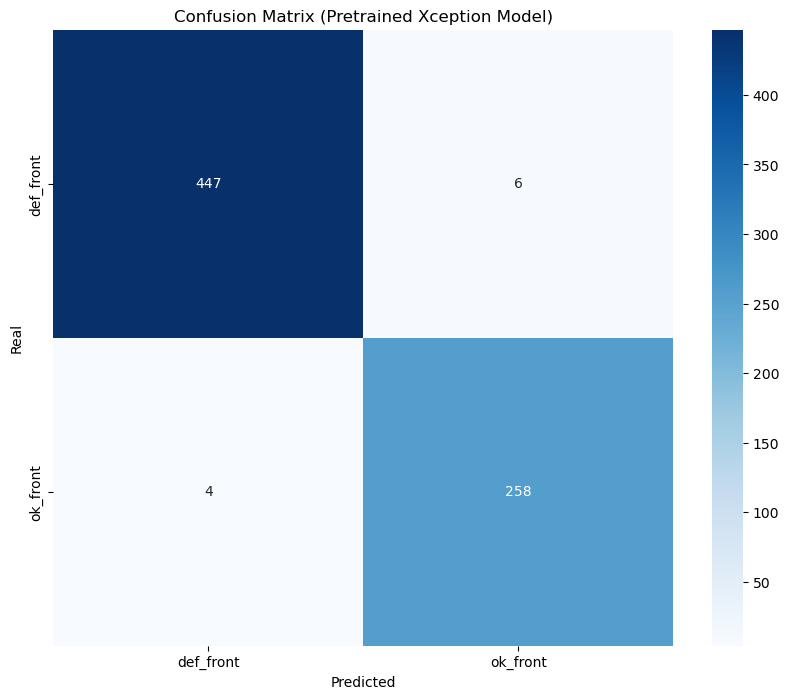

In [9]:
evaluation_inform(model_xception_pre, test_loader, device, classes)

In [10]:
# Load the model with no pretrained weights:    
model_xception_no_pre = timm.create_model('xception', pretrained=False)
model_xception_no_pre.fc = nn.Linear(n_features, n_classes) # Replace the final layer with a new one that has the correct number of output classes
model_xception_no_pre = model_xception_no_pre.to(device)

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [11]:
train = True

if train:
    train_model(model_xception_no_pre, epochs=10, save_dir = '../models/no_pretrained/xception_casting_model_no_pre.pth')

Epoch 1 | Loss: 0.6368815898895264
Epoch 2 | Loss: 0.5736351013183594
Epoch 3 | Loss: 0.33139240741729736
Epoch 4 | Loss: 0.5339417457580566
Epoch 5 | Loss: 0.3706117272377014
Epoch 6 | Loss: 0.37899380922317505
Epoch 7 | Loss: 0.5033361911773682
Epoch 8 | Loss: 0.24623911082744598
Epoch 9 | Loss: 0.5511949062347412
Epoch 10 | Loss: 0.4214555025100708


In [12]:
model_dir = '../models/no_pretrained/xception_casting_model_no_pre.pth'
model_xception_no_pre.load_state_dict(torch.load(model_dir))

<All keys matched successfully>

--- Classification Report --- 
              precision    recall  f1-score   support

   def_front       0.88      0.92      0.90       453
    ok_front       0.86      0.79      0.82       262

    accuracy                           0.87       715
   macro avg       0.87      0.86      0.86       715
weighted avg       0.87      0.87      0.87       715



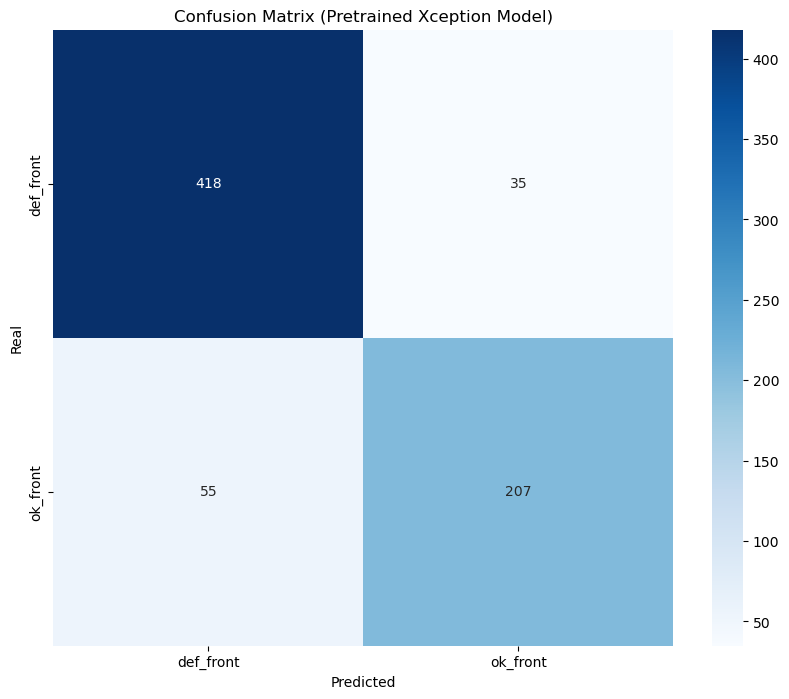

In [13]:
evaluation_inform(model_xception_no_pre, test_loader, device, classes)